In [7]:
import time

import numpy as np
import pandas as pd
import torch

import causalts.plotting as tp
from causalts.ci_tests import CMIknnGPU
from causalts.ci_tests import CMIKNN
from causalts.ci_tests import DFCITGPU
from causalts.ci_tests import GCMIGPU
from causalts.ci_tests import KCIGPU
from causalts.ci_tests import PartialCorr
from causalts.ci_tests import ParCorrGPU
from causalts.ci_tests import RCOTGPU
from causalts.ci_tests import SigKCIGPU
from causalts.ci_tests import SplitKCIGPU
from causalts import run_cdnots

%matplotlib inline

<a id="causalts-tutorial"></a>
# CausalTS Tutorial

A hands-on guide to time-series causal discovery with the `causalts` package.

| # | Method | Type | Description |
|---|--------|------|-------------|
| 1 | [**CDNOTS**](#cdnots) | Constraint-based | Causal discovery handling nonstationarity via a time/segment node |
| 2 | [**CEDAR**](#cedar) | Constraint-based | Scalable discovery using minimum-lag selection and distance correlation |
| 3 | [**GRACE**](#grace) | Hybrid | CDNOTS skeleton + neural gated refinement with $L_0$ regularization |
| 4 | [**Effect Estimation (DoWhy)**](#dowhy-bridge) | Post-discovery | See [dedicated notebook](examples/effect_estimation.ipynb) (optional) |

> For CI test documentation (KCIGPU, RCOTGPU, PartialCorr, ParCorrGPU, CMIknnGPU, GCMIGPU, SplitKCIGPU, DFCITGPU, SigKCIGPU), see the **API Reference** (`api_reference.ipynb`).  
> Run `causal-ts ci-test-info` for a quick CLI selection guide with benchmark F1 numbers.

<a id="cdnots"></a>
# CDNOTS

A constraint-based causal discovery method for time series data that can also handle nonstationarity by introducing an explicit time (or segment) node capturing distributional shifts. More details about the algorithm and its assumptions are in the paper [[arXiv:2312.17375](https://arxiv.org/abs/2312.17375)]. 

<a id="example-1-nonstationary-synthetic-time-series"></a>
## Example 1: Nonstationary Time Series

Suppose we have five nonstationary time series, with contemporaneous and lagged interdependence, and time as a time series itself (node $C$). They follow the model below:

\begin{align*}
    X^0_t &= 0.6 X^0_{t-1} + 0.3 X^1_{t-2} + 3\,(C^2 / 100000) + \epsilon^0_t\\
    X^1_t &= 0.8 X^1_{t-1} + 1.5\,(C^2 / 100000) + \epsilon^1_t\\
    X^2_t &= 0.6 X^2_{t-1} + \sin\,(C/20) + \epsilon^2_t\\
    X^3_t &= 0.5 X^3_{t-1} + 0.7 X^2_{t-2} + \epsilon^3_t\\
    X^4_t &= 0.5 X^4_{t-1} + 0.3 X^3_{t-1} + \epsilon^4_t\\
\end{align*}

To recover the causal structure of this model, we use the CDNOTS algorithm for time series. This algorithm consists of three phases: first, causal skeleton discovery; second, orienting the links between the time node and the other nonstationary nodes; and third, orienting the links between nonstationary nodes or nodes that have at least one nonstationary neighbor.

The adjacency matrix below shows the causal link orientations. 

$[j,i]=1$ and $[i,j]=-1$ indicate $i \to j$ (directed).

$[i,j]=[j,i]=-1$ indicates $i\text{—}j$ (undirected).

The table below shows the first five rows of the dataset. The dataset is structured in blocks of time. We have six variables (five time series plus $C$). The first six columns correspond to time $t$; the second six to time $t-1$ (lag 1); the third six to time $t-2$ (lag 2); and so on. Note that we treat variable $C$ as the sixth node (the last node if a different number of nodes is considered).

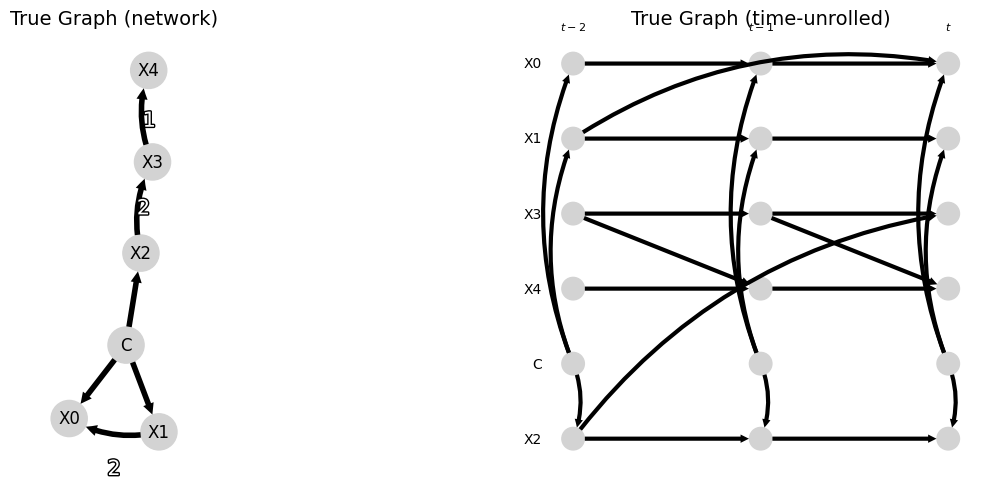

In [8]:
np.random.seed(32)
T = 300
max_lag = 2
ts = np.random.randn(T + max_lag, 5)
for i in range(max_lag, T + max_lag):
    ts[i, 0] += (
        0.6 * ts[i - 1, 0] + 0.3 * ts[i - 2, 1] + 3 * ((i - max_lag) ** 2 / 100000)
    )  # X1 -> X0
    ts[i, 1] += 0.8 * ts[i - 1, 1] + 1.5 * ((i - max_lag) ** 2 / 100000)
    ts[i, 2] += (
        0.6 * ts[i - 1, 2]
        + np.sin((i - max_lag) / 20)
    )
    ts[i, 3] += 0.5 * ts[i - 1, 3] + 0.7 * ts[i - 2, 2]  # X2 -> X3
    ts[i, 4] += 0.5 * ts[i - 1, 4] + 0.3 * ts[i - 1, 3]  # X3 -> X4

df = pd.DataFrame(ts[max_lag:], columns=["X" + str(i) for i in range(ts.shape[1])])

### True Graph based on the equations
true_graph = np.zeros((df.shape[1] + 1, df.shape[1] + 1, max_lag + 1))
true_graph[0, 0, 1] = 1  # X0,t-1 -> X0,t
true_graph[1, 0, 2] = 1  # X1,t-2 -> X0,t
true_graph[5, 0, 0] = 1  # C,t -> X0,t
true_graph[1, 1, 1] = 1  # X1,t-1 -> X1,t
true_graph[5, 1, 0] = 1  # C,t -> X1,t
true_graph[2, 2, 1] = 1  # X2,t-1 -> X2,t
true_graph[5, 2, 0] = 1  # C,t -> X2,t
true_graph[3, 3, 1] = 1  # X3,t-1 -> X3,t
true_graph[2, 3, 2] = 1  # X2,t-2 -> X3,t
true_graph[4, 4, 1] = 1  # X4,t-1 -> X4,t
true_graph[3, 4, 1] = 1  # X3,t-1 -> X4,t

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
tp.plot_graph(
    graph=true_graph,
    var_names=df.columns.tolist() + ["C"],
    link_label_fontsize=15,
    arrow_linewidth=4,
    show_colorbar=False,
    fig_ax=(fig, axes[0]),
)
axes[0].set_title("True Graph (network)", fontsize=14)
tp.plot_time_series_graph(
    true_graph, var_names=df.columns.tolist() + ["C"],
    arrow_linewidth=3, node_size=0.06,
    fig_ax=(fig, axes[1]),
)
axes[1].set_title("True Graph (time-unrolled)", fontsize=14)
plt.tight_layout()
plt.show()

import plotly.express as px
px.line(data_frame=df)

In [3]:
ci_test = PartialCorr(df.values, cache_dir=None, data_hash="ex1")
_r = run_cdnots(
    df=df, indep_test=ci_test, num_lags=2, include_C=True, alpha=0.1, stable=True
)
cg_linear, cg_tig_linear = _r, _r.cg_tig

In [5]:
ci_test_gcmi = GCMIGPU(
    df.values, device="cpu", cache_dir=None, data_hash="ex1_gcmi"
)
_r = run_cdnots(
    df=df, indep_test=ci_test_gcmi, num_lags=2, include_C=True, alpha=0.05, stable=True
)
cg_gcmi, cg_tig_gcmi = _r, _r.cg_tig

In [6]:
ci_test_kci_hbe = KCIGPU(
    df.values, approx="hbe", cache_dir=None, data_hash="ex1_kci"
)
_r = run_cdnots(
    df=df,
    indep_test=ci_test_kci_hbe,
    num_lags=2,
    include_C=True,
    alpha=0.05,
    stable=True,
)
cg_kci_hbe, cg_tig_kci_hbe = _r, _r.cg_tig

In [7]:
ci_test_rcot = RCOTGPU(
    df.values, num_f=100, num_f2=10, cache_dir=None, data_hash="ex1_rcot"
)
_r = run_cdnots(
    df=df, indep_test=ci_test_rcot, num_lags=2, include_C=True, alpha=0.05, stable=True
)
cg_rcot, cg_tig_rcot = _r, _r.cg_tig

In [8]:
ci_test_cmiknn = CMIknnGPU(
    df.values, device="cpu", k=0.2, early_stop=True,
    cache_dir=None, data_hash="ex1_cmiknn_gpu"
)
_r = run_cdnots(
    df=df, indep_test=ci_test_cmiknn, num_lags=2,
    include_C=True, alpha=0.05, stable=True,
)
cg_cmiknn, cg_tig_cmiknn = _r, _r.cg_tig

ci_test_splitkci = SplitKCIGPU(
    df.values, device="cpu",
    cache_dir=None, data_hash="ex1_splitkci"
)
_r = run_cdnots(
    df=df, indep_test=ci_test_splitkci, num_lags=2,
    include_C=True, alpha=0.05, stable=True,
)
cg_splitkci, cg_tig_splitkci = _r, _r.cg_tig

ci_test_dfcit = DFCITGPU(
    df.values, device="cpu", n_perm=500,
    cache_dir=None, data_hash="ex1_dfcit"
)
_r = run_cdnots(
    df=df, indep_test=ci_test_dfcit, num_lags=2,
    include_C=True, alpha=0.05, stable=True,
)
cg_dfcit, cg_tig_dfcit = _r, _r.cg_tig

ci_test_sigkci = SigKCIGPU(
    df.values, device="cpu", sigma=2.0, time_delay_dim=2,
    cache_dir=None, data_hash="ex1_sigkci"
)
_r = run_cdnots(
    df=df, indep_test=ci_test_sigkci, num_lags=2,
    include_C=True, alpha=0.05, stable=True,
)
cg_sigkci, cg_tig_sigkci = _r, _r.cg_tig

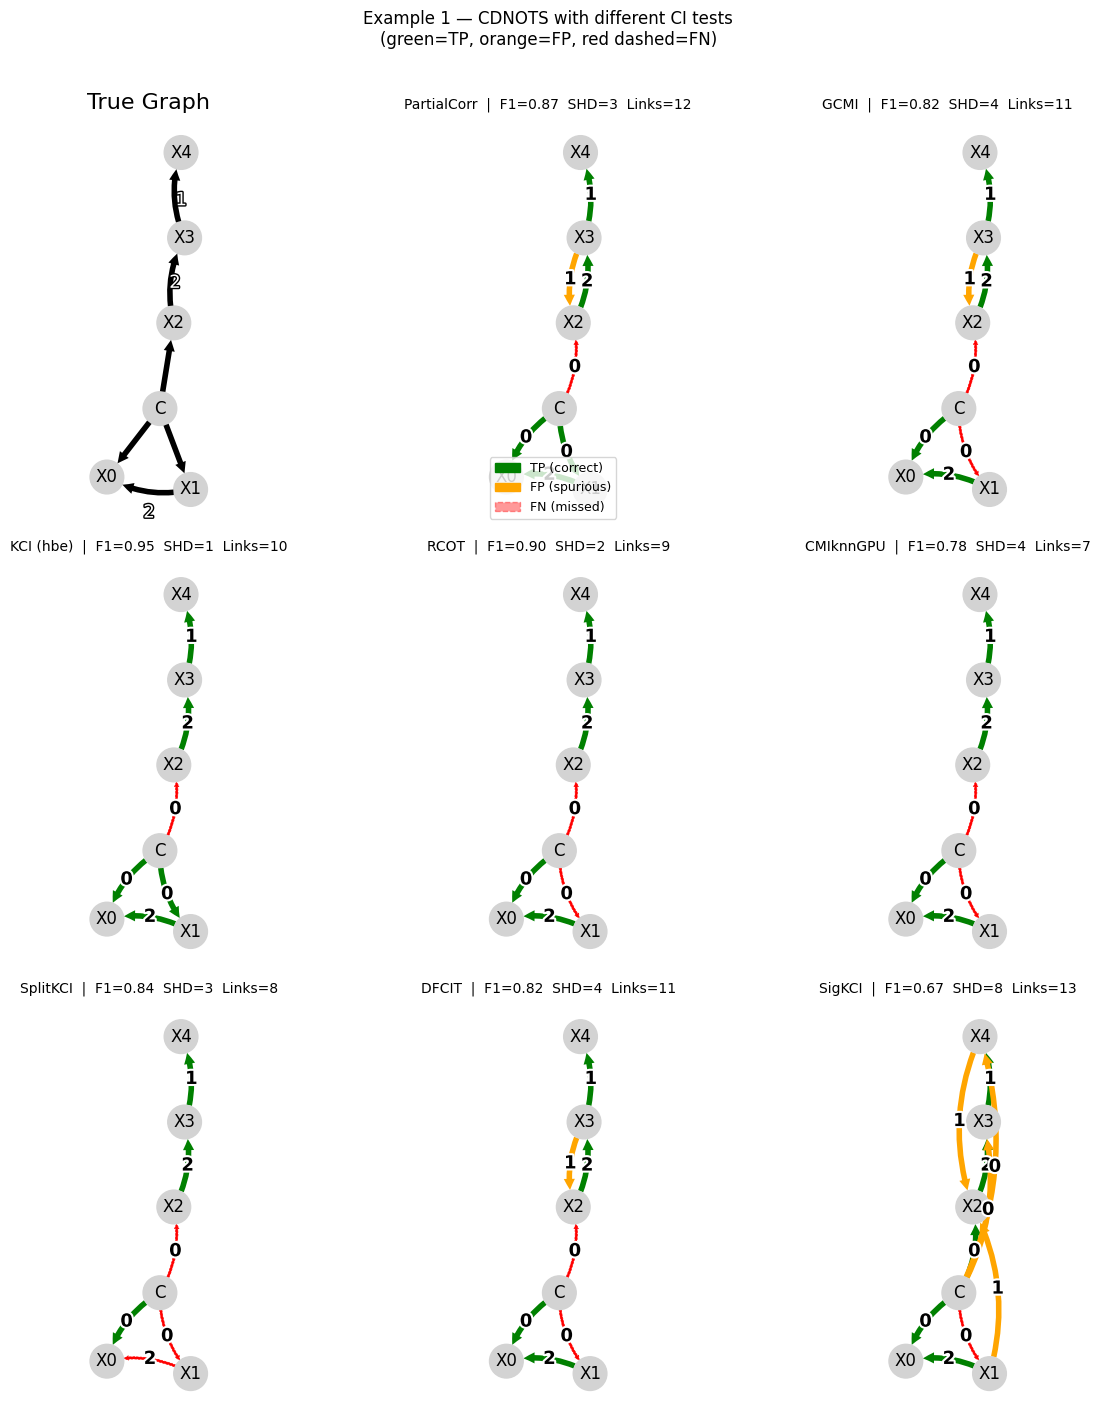

In [9]:
import matplotlib.pyplot as plt
from causalts.utils import evaluate_graph

var_names_ex1 = df.columns.tolist() + ["C"]

discovered = [
    ("PartialCorr",  cg_tig_linear),
    ("GCMI",         cg_tig_gcmi),
    ("KCI (hbe)",    cg_tig_kci_hbe),
    ("RCOT",         cg_tig_rcot),
    ("CMIknnGPU",    cg_tig_cmiknn),
    ("SplitKCI",     cg_tig_splitkci),
    ("DFCIT",        cg_tig_dfcit),
    ("SigKCI",       cg_tig_sigkci),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 14))

# Top-left: true graph alone
_, _, shared_pos = tp.plot_graph(
    graph=true_graph,
    var_names=var_names_ex1,
    link_label_fontsize=13,
    arrow_linewidth=4,
    show_colorbar=False,
    fig_ax=(fig, axes[0][0]),
    return_pos=True,
)
axes[0][0].set_title("True Graph", fontsize=16)

# Remaining 8 subplots: compare_graphs
for idx, (name, graph) in enumerate(discovered):
    row, col = divmod(idx + 1, 3)
    m = evaluate_graph(graph, true_graph)
    tp.compare_graphs(
        graph_true=true_graph,
        graph_discovered=graph,
        var_names=var_names_ex1,
        node_pos=shared_pos,
        arrow_linewidth=4,
        link_label_fontsize=13,
        # show_colorbar=False,
        show_legend=(idx == 0),
        legend_loc="lower left",
        fig_ax=(fig, axes[row][col]),
    )
    axes[row][col].set_title(
        f"{name}  |  F1={m['F1']:.2f}  SHD={m['SHD']}  Links={int(graph.sum())}",
        fontsize=10,
    )

fig.suptitle("Example 1 — CDNOTS with different CI tests\n(green=TP, orange=FP, red dashed=FN)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Each subplot shows TP edges (green), FP edges (orange), and FN edges (red dashed) against the true graph, with F1, SHD and link count in the title.

**Key observations:**
- **KCI (hbe)** and **KCI (sw)** capture most edges but miss the C→X2 link (KCI's gamma approximation can be conservative on nonstationarity signals).
- **DFCIT** has the highest recall — it is distribution-free and detects nonlinear C→X dependencies more reliably at T=300.
- **SplitKCI** matches KCI performance with 10–20× less compute.
- **SigKCI** may over-discover (extra FP edges) on this tabular lag-embedded data; it is best suited for path-structured SDE data.
- **PartialCorr** is the fastest and most precise on the linear edges, but misses the nonlinear C→X2 dependency.

<a id="example-2"></a>
## Example 2: 6-Node Linear VAR (ex2)

With limited data, nonlinear independence tests may perform unreliably due to their higher sample complexity and sensitivity to noise. In such scenarios, it is valuable to explore how well linear models—such as Vector Autoregressive (VAR) models—perform, especially when aligned with the underlying data structure.

In our case, the data-generating process is a VAR system, which provides an ideal opportunity to evaluate the performance of VAR-based methods under realistic conditions. Testing in this controlled setting allows us to assess both the strengths and limitations of these models when the assumptions are well specified.

In [10]:
from causalts.synthetic_data.synthetic_datasets import ex2

result_ex2 = ex2(seed=42, T=300)
df = result_ex2["df"]
max_lag = result_ex2["max_lag"]

# True graph with C node slot (CDNOTS adds C as last node)
true_graph_ex2 = np.zeros((df.shape[1] + 1, df.shape[1] + 1, max_lag + 1))
true_graph_ex2[:df.shape[1], :df.shape[1], :] = result_ex2["ground_truth"]

<a id="var"></a>
#### VAR 

In [15]:
from statsmodels.tsa.api import VAR
from causalts.utils import evaluate_graph as _eval

mdl = VAR(df.values, exog=None, dates=None, freq=None, missing="none")
mdl_fit = mdl.fit(maxlags=max_lag, trend="n")

n_vars = df.shape[1]
n_lags_fit = mdl_fit.k_ar

# Extract significant edges from VAR p-values
pvals = mdl_fit.pvalues  # shape: (n_lags_fit * n_vars, n_vars)
grph_var = np.zeros((n_vars, n_vars, max_lag + 1))
for lag in range(1, n_lags_fit + 1):
    block = pvals[(lag - 1) * n_vars : lag * n_vars, :]  # (n_vars, n_vars)
    sig = (block <= 0.05).astype(float)
    grph_var[:, :, lag] = sig.T  # [cause, effect, lag]

# Remove autodependencies for cleaner plot
for i in range(n_vars):
    grph_var[i, i, :] = 0

m_var = _eval(grph_var, result_ex2["ground_truth"])
print(f"VAR(p={n_lags_fit}): F1={m_var['F1']:.3f}, SHD={m_var['SHD']}, "
      f"Precision={m_var['Precision']:.3f}, TPR={m_var['TPR']:.3f}")

VAR(p=3): F1=0.231, SHD=20, Precision=0.200, TPR=0.273


In [27]:
# Run discovery for all tests
results = {}
tests = {
    "KCIGPU": KCIGPU(data=df.values, cache_dir=None, data_hash="example2_kci"),
    "RCOTGPU": RCOTGPU(
        data=df.values, cache_dir=None, data_hash="example2_rcot"
    ),
    "PartialCorr": ParCorrGPU(
        data=df.values, cache_dir=None, data_hash="example2_parcorr"
    ),
    "CMIKNN": CMIknnGPU(
        data=df.values,
        cache_dir=None,
        data_hash="example2_cmiknn",
        early_stop=True,
        target_quantile=0.05,
        sig_samples=200,
        workers=,
    ),
}

for test_name, test in tests.items():
    print(f"Running discovery with {test_name}...")
    _r = run_cdnots(
        df=df,
        indep_test=test,
        num_lags=max_lag,
        include_C=True,
        alpha=0.05,
        stable=True,
    )

    results[test_name] = _r.cg_tig

# Add the true graph and VAR to results for plotting
# Pad VAR graph to include C node dimension for consistent plotting
grph_var_c = np.zeros((n_vars + 1, n_vars + 1, max_lag + 1))
grph_var_c[:n_vars, :n_vars, :] = grph_var
results["True Graph"] = true_graph_ex2
results["VAR"] = grph_var_c

Running discovery with KCIGPU...
Running discovery with RCOTGPU...
Running discovery with PartialCorr...
Running discovery with CMIKNN...


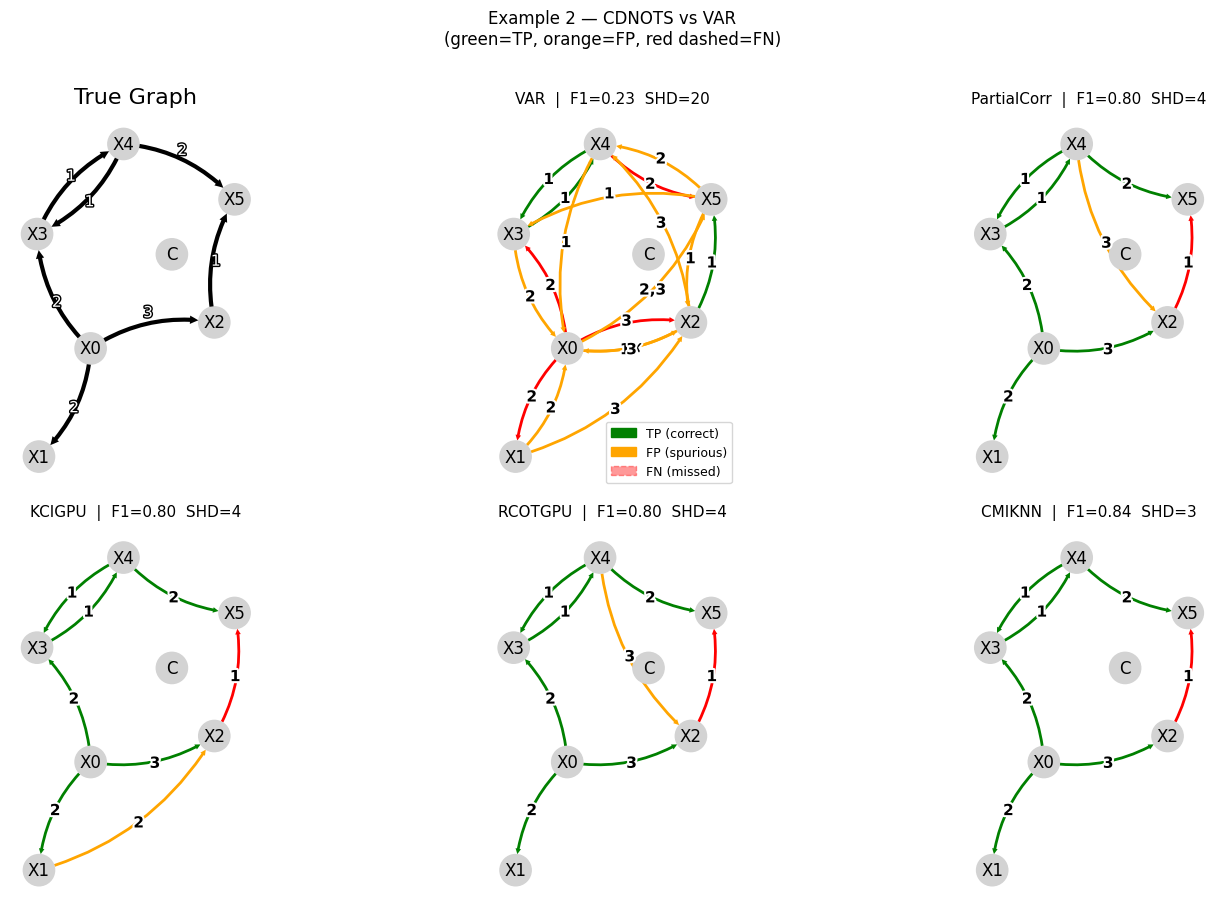

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Top-left: true graph
_, _, shared_pos = tp.plot_graph(
    graph=true_graph_ex2,
    var_names=df.columns.tolist() + ["C"],
    link_label_fontsize=11,
    arrow_linewidth=3,
    show_colorbar=False,
    node_size=0.2,
    node_layout="neato",
    fig_ax=(fig, axes[0][0]),
    return_pos=True,
)
axes[0][0].set_title("True Graph", fontsize=16)

# Remaining subplots: compare_graphs (TP=green, FP=orange, FN=red dashed)
compare_items = [
    ("VAR", grph_var_c),
    ("PartialCorr", results["PartialCorr"]),
    ("KCIGPU", results["KCIGPU"]),
    ("RCOTGPU", results["RCOTGPU"]),
    ("CMIKNN", results["CMIKNN"]),
]
for idx, (name, graph) in enumerate(compare_items):
    row, col = divmod(idx + 1, 3)
    m = _eval(graph, true_graph_ex2)
    tp.compare_graphs(
        graph_true=true_graph_ex2,
        graph_discovered=graph,
        var_names=df.columns.tolist() + ["C"],
        node_pos=shared_pos,
        arrow_linewidth=2,
        link_label_fontsize=11,
        node_size=0.2,
        show_legend=(idx == 0),
        fn_linewidth=2, fn_style="solid",
        legend_loc="lower right",
        fig_ax=(fig, axes[row][col]),
    )
    axes[row][col].set_title(
        f"{name}  |  F1={m['F1']:.2f}  SHD={m['SHD']}",
        fontsize=11,
    )

fig.suptitle("Example 2 — CDNOTS vs VAR\n(green=TP, orange=FP, red dashed=FN)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()



Our evaluation of different causal discovery methods highlights several key findings:

- **VAR-based approach** identified all true causal links but also introduced several spurious (false positives), indicating a tendency to overfit and misattribute dependencies, especially in the presence of noise or weak signals.

- **CDNOTS with CMIknn** emerged as the **most precise** method in this setting, successfully recovering all true links except for one weak connection from **X2 to X5**, which it failed to detect.


## Advanced Data Handling

For handling special data types, see the dedicated example notebooks:

- **[Missing Values](examples/missing_values.ipynb)** — Pairwise-complete, VAR-EM, and causal iterative imputation
- **[Mixed Discrete-Continuous Data](examples/mixed_data.ipynb)** — Automatic stratified CI testing for binary/categorical variables


<a id="cedar"></a>
# CEDAR

The CEDAR algorithm is a constraint-based method for causal discovery in autoregressive time series, designed to reduce the computational burden of traditional conditional independence (CI)–based approaches. Building on the original SyPI framework, which constructs conditioning sets directly to avoid exhaustive searches, CEDAR extends the method to handle nonlinear dependencies. The algorithm identifies potential causal links by testing only two CI relations per candidate variable, guided by the concept of a minimum lag—the earliest time lag at which one series can influence another without collider interference. To detect nonlinear dependencies across lags, CEDAR employs measures such as distance correlation rather than linear regression. After constructing an initial graph, it introduces a pruning step to eliminate false positives that may arise when assumptions about sink nodes are relaxed. This design ensures that the algorithm grows in complexity only quadratically with the number of variables, rather than exponentially, making it both scalable and efficient while remaining consistent with causal discovery theory.

In [4]:
from causalts.cedar import run_cedar

<a id="example-3"></a>
## Example 3: Cascade Network (ex3, d=11)

In [5]:
from causalts.synthetic_data.synthetic_datasets import ex3

result_ex3 = ex3(seed=42, T=300)
df_ex3 = result_ex3["df"]
var_names = df_ex3.columns.tolist()
true_graph_ex3 = result_ex3["ground_truth"]
maxlag = result_ex3["max_lag"]

CedarResult(vars=11, max_lag=3, edges=26, lag_method='dcor', lag_pvalue_method='t_test', alpha_cond1=0.01, alpha_cond2=0.01, pruned=True, n_tests=104)


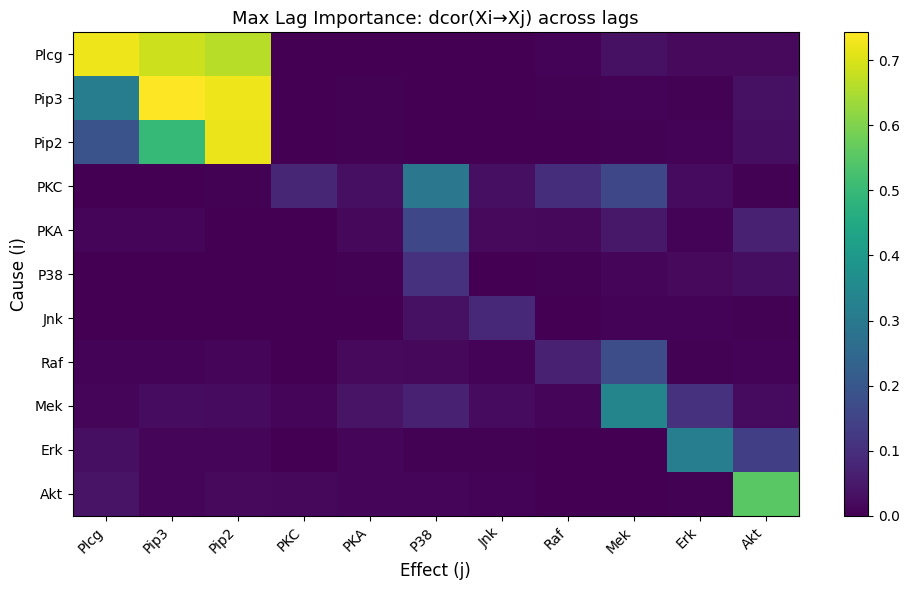

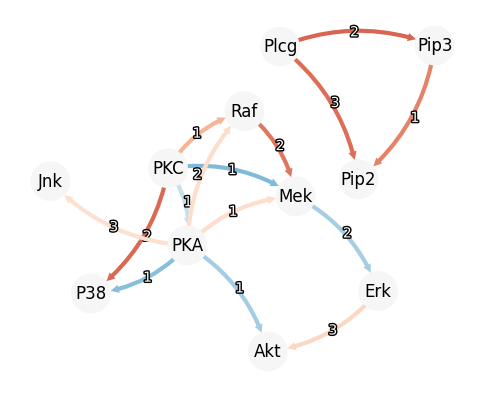

In [6]:
import matplotlib.pyplot as plt

tests = {
    "KCIGPU": KCIGPU(
        data=df_ex3.values, cache_dir=None, data_hash="example3_kci"
    ),
    "RCOTGPU": RCOTGPU(
        data=df_ex3.values, cache_dir=None, data_hash="example3_rcot"
    ),
    "PartialCorr": PartialCorr(
        data=df_ex3.values, cache_dir=None, data_hash="example3_parcorr"
    ),
    "CMIKNN": CMIKNN(
        data=df_ex3.values,
        cache_dir=None,
        data_hash="example3_cmiknn",
        early_stop=True,
        target_quantile=0.05,
        sig_samples=200,
        workers=2,
    ),
}

cedar_result = run_cedar(
    df=df_ex3,
    ci_test=tests["PartialCorr"],
    max_lag=maxlag,
    alpha_cond1=0.01,
    alpha_cond2=0.01,
    lag_method="dcor",
    normalize="minmax",
    filter_children=True,
    prune=True,
    verbose=True,
)
print(cedar_result)

# Lag importance heatmap — max distance correlation across lags
lag_imp_max = cedar_result.lag_importance.max(axis=2)  # (d, d)
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(lag_imp_max, aspect="auto", cmap="viridis", vmin=0)
ax.set_xticks(range(len(var_names)))
ax.set_yticks(range(len(var_names)))
ax.set_xticklabels(var_names, rotation=45, ha="right")
ax.set_yticklabels(var_names)
ax.set_xlabel("Effect (j)", fontsize=12)
ax.set_ylabel("Cause (i)", fontsize=12)
ax.set_title("Max Lag Importance: dcor(Xi→Xj) across lags", fontsize=13)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

cedar_result.plot(var_names=var_names, figsize=(6, 6), show_colorbar=False)
plt.show()

 Now we solve it with CDNOTS

In [ ]:
include_C = True
_r = run_cdnots(
    df=df_ex3,
    indep_test=tests["PartialCorr"],
    num_lags=3,
    include_C=include_C,
    alpha=0.05,
    stable=True,
    return_pvals=True,
)
cg_cdnots_ex3 = _r.cg_tig

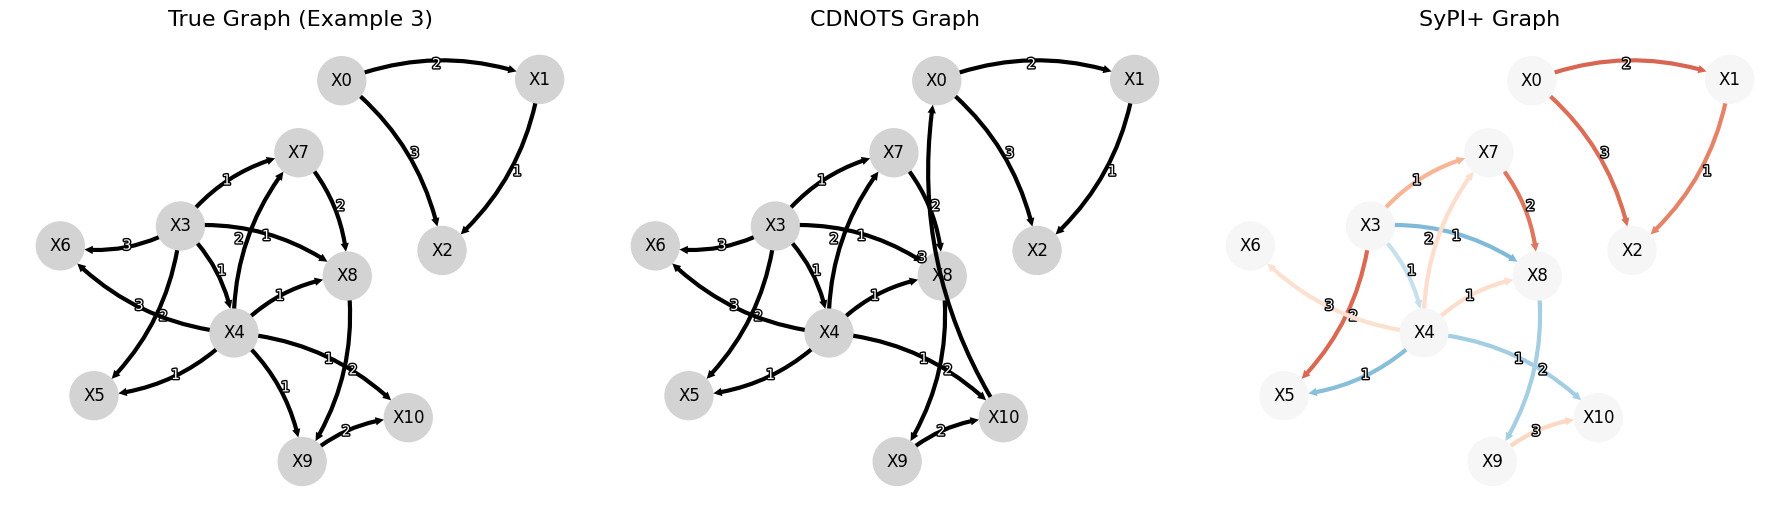

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pos = tp.plot_graph(
    graph=true_graph_ex3,
    var_names=var_names,
    link_label_fontsize=10,
    arrow_linewidth=3,
    fig_ax=(fig, axes[0]),
    return_pos=True,
)
axes[0].set_title("True Graph (Example 3)", fontsize=16)

tp.plot_graph(
    graph=cg_cdnots_ex3[:-1, :-1, :],  # Remove C node
    var_names=var_names,
    link_label_fontsize=10,
    arrow_linewidth=3,
    fig_ax=(fig, axes[1]),
    node_pos=pos[2],  # Use same layout as true graph for easier comparison
)
axes[1].set_title("CDNOTS Graph", fontsize=16)

cedar_result.plot(
    fig_ax=(fig, axes[2]),
    var_names=var_names,
    node_size=0.2,
    arrow_linewidth=3,
    show_colorbar=False,
    node_pos=pos[2],  # Use same layout as true graph for easier comparison
)
axes[2].set_title("CEDAR Graph", fontsize=16)

plt.tight_layout()
plt.show()

As shown above, CEDAR identified all links, whereas CDNOTS missed two. However, as more data becomes available, CDNOTS is expected to improve, since the CI tests become more accurate with larger samples.

While CEDAR achieves scalability by requiring only two conditional independence tests to determine whether a link should be included or excluded, this efficiency comes with a potential drawback. Because the decision rests on a very small number of tests, the algorithm can be more sensitive to the reliability and robustness of those test outcomes. In contrast, algorithms such as CDNOTS rely on a more extensive battery of conditional independence tests, which can reduce sensitivity to any single test result but at the cost of higher computational complexity. Thus, the linear runtime and scalability of CEDAR may entail a trade-off in terms of sensitivity to test accuracy, particularly in noisy or small-sample settings.

<a id="grace"></a>
# GRACE

**GRACE** (Gated Refinement for Accurate Causal Edge discovery) is a two-stage framework for high-dimensional time-series causal discovery.

**Stage 1 — Skeleton:** Run CDNOTS with fast linear CI tests (partial correlation) to produce a high-recall skeleton. This is fast but may include false positives, especially at high dimensionality.

**Stage 2 — Gated Refinement:** A neural model assigns each candidate edge an independent Hard Concrete gate trained with $L_0$ regularization. Gates that don't improve prediction are driven to exact zero — no post-hoc thresholding needed. The regularization strength $\lambda$ is set automatically based on skeleton density.

GRACE is most impactful at high dimensionality ($d \geq 20$), where constraint-based skeletons have many false positives that the gated model can prune.

In [4]:
from causalts.grace import run_cdnots_gated
from causalts.cdnots import run_cdnots_plus
from causalts.ci_tests import PartialCorr
from causalts.utils import evaluate_graph
from causalts.synthetic_data.synthetic_datasets import SCPGraphGenerator
import causalts.plotting as tp
import numpy as np
import matplotlib.pyplot as plt

<a id="example-4"></a>
## Example 4: High-Dimensional Random SCP (d=30)

We generate a random sparse SCP graph with $d=30$ variables, $T=1000$ samples, and maximum lag 5, 
mixing linear and nonlinear mechanisms. We use **CDNOTS+** to produce a high-recall skeleton, 
then apply **GRACE** gated refinement to prune false positives while preserving recall.

In [5]:
gen = SCPGraphGenerator(n_vars=30, max_lag=5)
result = gen.sample(seed=42, T=1000)

df = result["df"]
true_graph = result["ground_truth"]
var_names = result["var_names"]
max_lag = result["max_lag"]

print(f"Variables: {len(var_names)}, Samples: {len(df)}, Max lag: {max_lag}")
print(f"True edges: {int(true_graph.sum())}")

Variables: 30, Samples: 1000, Max lag: 5
True edges: 61


In [ ]:
import warnings
warnings.filterwarnings("ignore", message="std\\(\\): degrees of freedom")

# Step 1: Get CDNOTS+ skeleton (high recall, more FPs for GRACE to prune)
ci = PartialCorr(data=df.values)
res_plus = run_cdnots_plus(
    df=df, indep_test=ci, num_lags=max_lag,
    include_C=True, alpha=0.05, show_progress=True,
)
d = len(var_names)
plus_skeleton = res_plus.cg_tig[:d, :d, :].astype(np.int8)
print(f"CDNOTS+ skeleton: {int(plus_skeleton.sum())} edges")

# Step 2: GRACE gated refinement on the CDNOTS+ skeleton
res_grace = run_cdnots_gated(
    df=df,
    max_lag=max_lag,
    skeleton=plus_skeleton,
    verbose=True,
    device="mps",
    model_seed=42,
)
print(f"GRACE output: {int(res_grace.cg_tig.sum())} edges")

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

CDNOTS+ skeleton: 117 edges


Metric       CDNOTS+      GRACE       
-------------------------------------------------------
TPR               1.000      1.000
Precision         0.521      0.782
F1                0.685      0.878
FP                   56         17
SHD                  56         17


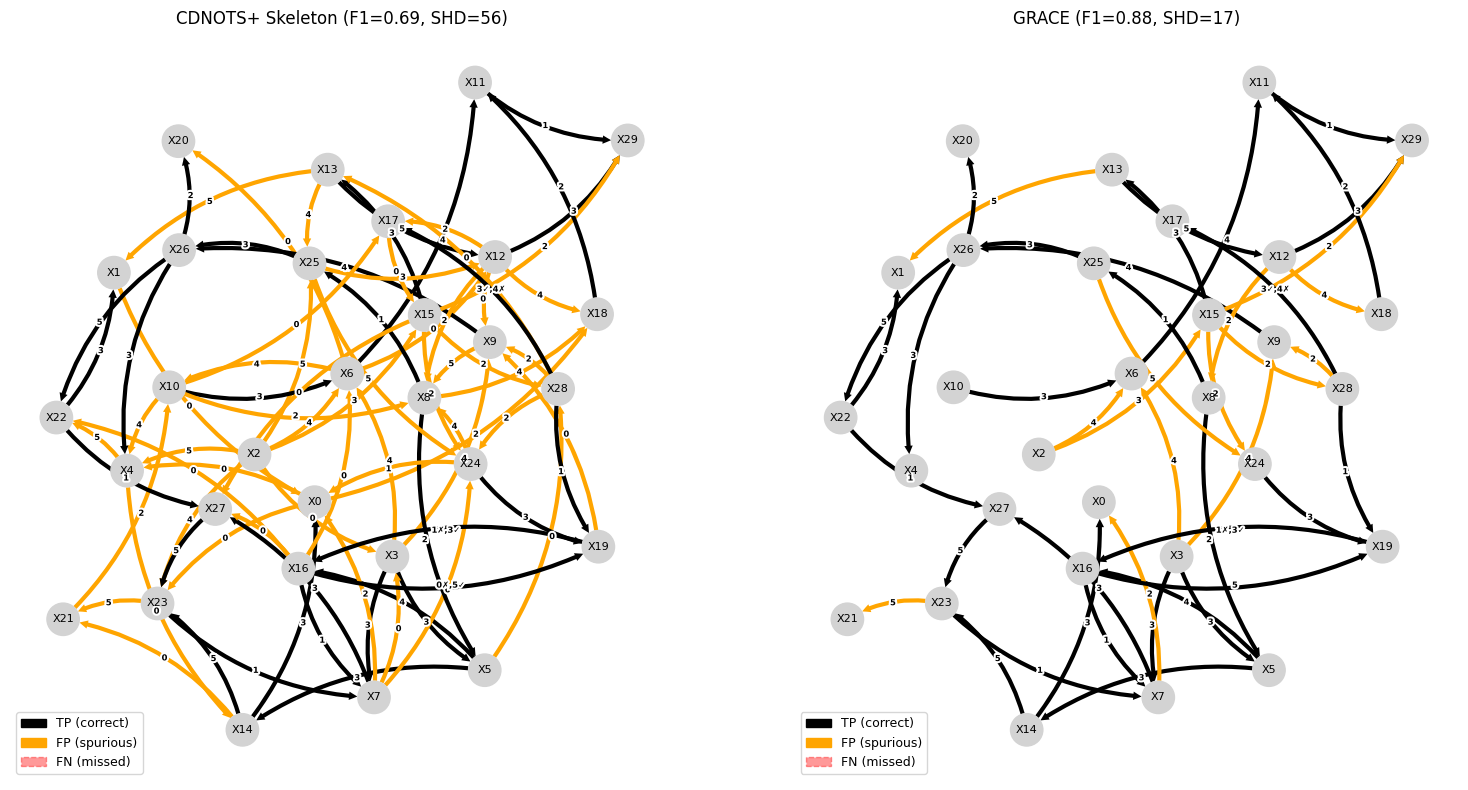

In [12]:
# Evaluate CDNOTS+ skeleton
skel_metrics = evaluate_graph(plus_skeleton, true_graph)

# Evaluate GRACE (gated refinement)
grace_metrics = evaluate_graph(res_grace.cg_tig, true_graph)

print("=" * 55)
print(f"{'Metric':<12} {'CDNOTS+':<12} {'GRACE':<12}")
print("-" * 55)
for key in ["TPR", "Precision", "F1", "FP", "SHD"]:
    sv = skel_metrics[key]
    gv = grace_metrics[key]
    fmt = '.3f' if isinstance(sv, float) else 'd'
    print(f"{key:<12} {sv:>10{fmt}} {gv:>10{fmt}}")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

_, _, pos = tp.compare_graphs(
    graph_true=true_graph, graph_discovered=plus_skeleton,
    var_names=var_names, node_layout="fdp",
    node_size=0.10, arrow_linewidth=3, link_label_fontsize=6,
    title=f"CDNOTS+ Skeleton (F1={skel_metrics['F1']:.2f}, SHD={skel_metrics['SHD']})",
    legend_loc="lower left", tp_color="black",
    fig_ax=(fig, axes[0]), return_pos=True, node_label_size=8,
)

tp.compare_graphs(
    graph_true=true_graph, graph_discovered=res_grace.cg_tig,
    var_names=var_names,
    node_size=0.10, arrow_linewidth=3, link_label_fontsize=6,
    title=f"GRACE (F1={grace_metrics['F1']:.2f}, SHD={grace_metrics['SHD']})",
    legend_loc="lower left", tp_color="black",
    fig_ax=(fig, axes[1]), node_pos=pos, node_label_size=8,
)

plt.tight_layout()
plt.show()

**Results:** GRACE preserves the high recall of the CDNOTS+ skeleton (TPR unchanged) while 
pruning false positives — precision improves substantially and SHD drops. 
CDNOTS+ produces a high-recall skeleton with more candidate edges, giving GRACE 
meaningful material to evaluate and prune via its neural gates with L0 regularization.

---

<a id="dowhy-bridge"></a>
# Effect Estimation (DoWhy)

After discovering the causal graph, you can estimate causal effects, fit structural causal models, run counterfactual analysis, and perform root cause attribution using the optional DoWhy integration.

See **[examples/effect_estimation.ipynb](examples/effect_estimation.ipynb)** for a comprehensive end-to-end demo covering:

1. Effect estimation (ATE with confidence intervals)
2. SCM fitting + counterfactual analysis
3. Root cause attribution (Shapley-based)
4. Graph falsification (no ground truth needed)
5. Structural refutation
6. Arrow strength + parent relevance
7. Distribution change detection (concept drift)
8. GRACE integration via wrap_graph()

Install: `pip install causalts[dowhy]`